# **3. Train and Test ML algorithm in Materials - Unsupervised Learning(Assignment)**

In [3]:
!pip install matminer[citrine] -q # install matminer library
!pip install pyyaml -q
!pip install pymatgen -q
!pip install --upgrade pyyaml six matminer[citrine] citrination-client pymatgen -q
!pip install numpy==1.26.4 pandas==2.2.2 matplotlib==3.9.0 - q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 6.6 MB/s eta 0:00:00
ERROR: Invalid requirement: '-': Expected package name at the start of dependency specifier
    -
    ^


In [14]:
# Task: Load the elastic tensor dataset from matminer and keep only the columns "material_id" and "K_Voigt"
from matminer.datasets.convenience_loaders import load_elastic_tensor

#df = load_elastic_tensor()  # load the dataset in a pandas DataFrame object
df.XXXXX # check columns
df = df[["XXXXX","XXXXXX"]]
df.head()

,material_id,K_Voigt
0,mp-10003,194.270146
1,mp-10010,177.252050
2,mp-10015,295.077545
3,mp-10021,49.235377
4,mp-10025,258.480904


In [16]:
# Task: Exclude the column "material_id" from the dataset and create a new DataFrame X
excluded = ["XXXXX"]
X = df.XXXX(XXXX, XXXX=X)
X.head()

,K_Voigt
0,194.270146
1,177.252050
2,295.077545
3,49.235377
4,258.480904


In [17]:
# Task: Apply Agglomerative Clustering (Ward linkage) to the dataset X, measure the elapsed time, and obtain the cluster labels
#The agglomerative clustering is the most common type of hierarchical clustering used to group objects in clusters based on their similarity.
#It’s also known as AGNES (Agglomerative Nesting). The algorithm starts by treating each object as a singleton cluster.
#Next, pairs of clusters are successively merged until all clusters have been merged into one big cluster containing all objects.
import time as time
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import AgglomerativeClustering
import sklearn.datasets
#The method of merging two clusters involves combining the two clusters that result in the smallest increase in the variance within all clusters.(Ward)
print("Compute unstructured hierarchical clustering...")
st = XXXX.XXXXX()
ward = XXXX(XXXXX=6, XXXXX="XXXXX").fit(X)
elapsed_time = time.time() - st
group = XXXXX
print(f"Elapsed time: {elapsed_time:.2f}s")
print(f"Number of points: {group.size}")

Compute unstructured hierarchical clustering...
Elapsed time: 0.17s
Number of points: 1181


In [7]:
group

array([0, 0, 4, ..., 5, 5, 2])

In [18]:
# Task: Add the cluster labels as a new column "group" to the DataFrame and display the updated DataFrame
df['XXXXX'] = XXXXX.XXXXX()
df

,material_id,K_Voigt,group
0,mp-10003,194.270146,0
1,mp-10010,177.252050,0
2,mp-10015,295.077545,4
3,mp-10021,49.235377,2
4,mp-10025,258.480904,3
...,...,...,...
1176,mp-9961,113.178476,1
1177,mp-9969,101.446005,1
1178,mp-9972,89.419968,5
1179,mp-998,99.386015,5


In [27]:
#AgglomerativeClustering --> many clusters --> connectivity constraints 필요 (only adjacent clusters can be merged together), through a connectivity matrix that defines for each sample the neighboring samples following a given structure of the data.
#For instance, in the swiss-roll example below, the connectivity constraints forbid the merging of points that are not adjacent on the swiss roll, and thus avoid forming clusters that extend across overlapping folds of the roll.
#The connectivity constraints are imposed via an connectivity matrix: a scipy sparse matrix that has elements only at the intersection of a row and a column with indices of the dataset that should be connected
from sklearn.neighbors import kneighbors_graph

connectivity = kneighbors_graph(X, n_neighbors=1, include_self=False)
print("Compute structured hierarchical clustering...")
st = time.time()
ward = AgglomerativeClustering(
    n_clusters=6, connectivity=connectivity, linkage="ward"
).fit(X)
elapsed_time = time.time() - st
group = ward.labels_
print(f"Elapsed time: {elapsed_time:.2f}s")
print(f"Number of points: {group.size}")

#Connectivity constraints and single, complete or average linkage can enhance the ‘rich getting richer’ aspect of agglomerative clustering, particularly so if they are built with sklearn.neighbors.kneighbors_graph.
#In the limit of a small number of clusters, they tend to give a few macroscopically occupied clusters and almost empty ones. (see the discussion in Agglomerative clustering with and without structure).
#Single linkage is the most brittle linkage option with regard to this issue.

Compute structured hierarchical clustering...


/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:325: UserWarning: the number of connected components of the connectivity matrix is 388 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


Elapsed time: 21.27s
Number of points: 1181


In [29]:
group

array([0, 0, 4, ..., 5, 5, 2])

In [23]:
df['group'] = group.tolist()

df

,material_id,K_Voigt,group
0,mp-10003,194.270146,0
1,mp-10010,177.252050,0
2,mp-10015,295.077545,4
3,mp-10021,49.235377,2
4,mp-10025,258.480904,3
...,...,...,...
1176,mp-9961,113.178476,1
1177,mp-9969,101.446005,1
1178,mp-9972,89.419968,5
1179,mp-998,99.386015,5


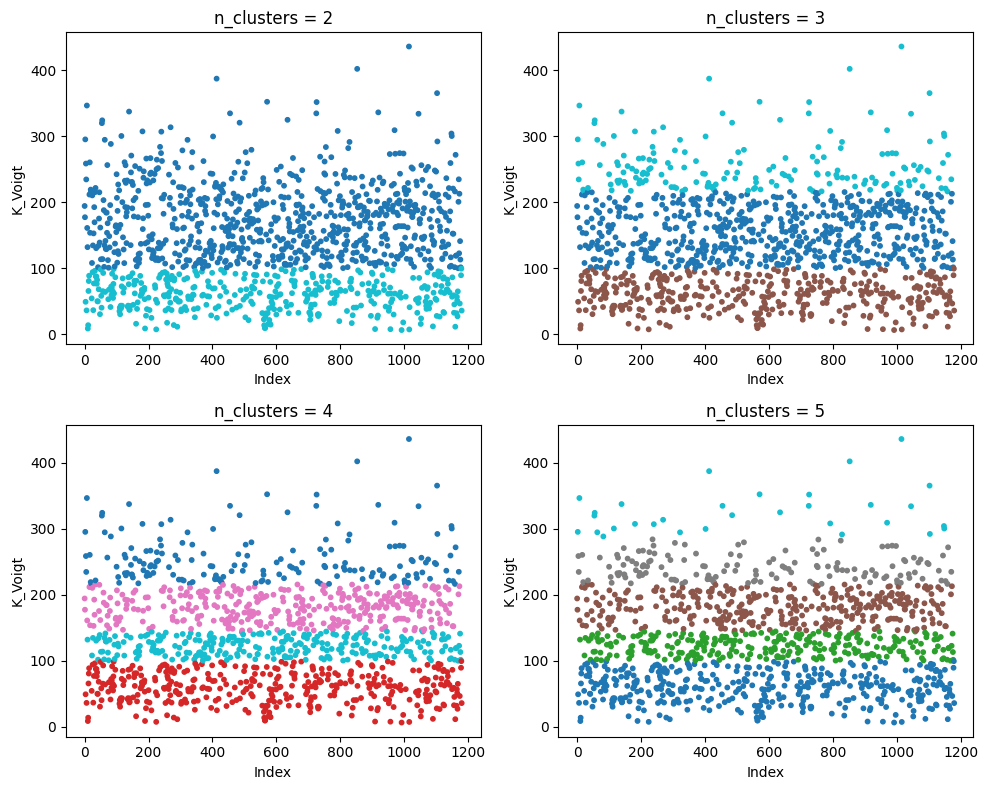

In [30]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

X_vis = np.column_stack([np.arange(len(X)), X.values.ravel()])
x_label, y_label = "Index", X.columns[0]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, n_clusters in zip(axes.flatten(), [2, 3, 4, 5]):
    model = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
    labels = model.fit_predict(X)

    scatter = ax.scatter(X_vis[:, 0], X_vis[:, 1], c=labels, cmap="tab10", s=10)
    ax.set_title(f"n_clusters = {n_clusters}")
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

plt.tight_layout()
plt.show()
